# Notebook 3: Logistic Regression — Liver Cancer Gene Expression

**Input files:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Task:** Binary classification — HCC vs Normal

---

**What this notebook does:**
1. Loads the preprocessed train/test sets from Notebook 2
2. Explains how Logistic Regression works
3. Trains a baseline Logistic Regression model
4. Tunes hyperparameters using GridSearchCV
5. Evaluates the best model — F1, AUC, classification report
6. Plots the confusion matrix, ROC curve, and top feature coefficients

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

class_pos   = 'HCC'
class_neg   = 'normal'
random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Preprocessed Data

In [3]:
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_test  = pd.read_csv(data_dir / 'X_test.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv').squeeze()

print(f'X_train : {X_train.shape}   |   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    |   y_test  : {y_test.shape}')
print()
print(f'Train — {class_pos}: {(y_train == class_pos).sum()}  |  {class_neg}: {(y_train == class_neg).sum()}')
print(f'Test  — {class_pos}: {(y_test  == class_pos).sum()}  |  {class_neg}: {(y_test  == class_neg).sum()}')

X_train : (285, 30)   |   y_train : (285,)
X_test  : (72, 30)    |   y_test  : (72,)

Train — HCC: 144  |  normal: 141
Test  — HCC: 37  |  normal: 35


## 4. How Logistic Regression Works

Logistic Regression is a **linear classifier** that models the probability that a sample belongs to a given class.

### The Core Idea
For each sample, the model computes a weighted sum of its features:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

This raw score $z$ is then passed through the **sigmoid function** to produce a probability between 0 and 1:

$$P(\text{HCC}) = \frac{1}{1 + e^{-z}}$$

If $P(\text{HCC}) \geq 0.5$, the sample is predicted as HCC; otherwise Normal.

### Why it suits gene expression data
- With thousands of gene features, Logistic Regression uses **regularisation** (penalty on the weights) to prevent overfitting. We test both **L1** (Lasso — drives unimportant weights to zero) and **L2** (Ridge — shrinks all weights smoothly).
- The learned **coefficients** directly tell us which genes push a sample toward HCC (positive coefficient) or Normal (negative coefficient) — making the model **interpretable**.
- Because the data was already scaled in Notebook 2, coefficients are on the same scale and can be compared fairly.

### Key hyperparameters we will tune
| Parameter | What it controls |
|-----------|------------------|
| `C` | Inverse of regularisation strength. Small C = stronger regularisation (simpler model). Large C = weaker regularisation (fits training data more closely). |
| `penalty` | Type of regularisation: `l1` (sparse, zeroes out weak genes) or `l2` (ridge, keeps all genes but small). |

## 5. Baseline Logistic Regression

In [4]:
baseline_lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=random_seed
)
baseline_lr.fit(X_train, y_train)
y_pred_base = baseline_lr.predict(X_test)
y_prob_base = baseline_lr.predict_proba(X_test)[:, list(baseline_lr.classes_).index(class_pos)]

base_f1  = f1_score(y_test, y_pred_base, pos_label=class_pos)
base_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_base)

print('Baseline Logistic Regression:')
print(f'  F1 score : {base_f1:.4f}')
print(f'  ROC-AUC  : {base_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=[class_pos, class_neg]))

Baseline Logistic Regression:
  F1 score : 0.9275
  ROC-AUC  : 0.9768

              precision    recall  f1-score   support

         HCC       1.00      0.86      0.93        37
      normal       0.88      1.00      0.93        35

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72



### Interpretation of Baseline Results

* **Strong Overall Performance:** The model achieves an **F1-score of 0.93** for detecting HCC right out of the box — highly accurate with no tuning at all.
* **Perfect Precision:** Every sample the model flagged as HCC was genuinely cancerous (Precision = 1.00). There were **zero false alarms**.
* **Some Missed Cancers:** The model missed 5 of the 37 HCC cases in the test set (Recall = 0.86). In a medical context, missed cancers are the more dangerous type of error, so this is the key number to watch.
* **Excellent ROC-AUC:** The model achieved a ROC-AUC of 0.9768, indicating exceptional ability to rank HCC samples above normal samples across all probability thresholds.

## 6. Hyperparameter Tuning — GridSearchCV

We search over a grid of `C` values and penalty types using 5-fold stratified cross-validation, scoring by F1.

| Parameter | Values searched |
|-----------|----------------|
| `C` | 0.001, 0.01, 0.1, 1, 10, 100 |
| `penalty` | `l1`, `l2` |
| `solver` | `liblinear` (supports both L1 and L2) |

In [5]:
from sklearn.metrics import make_scorer

param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Create a custom F1 scorer that knows which label is the positive class
custom_f1_scorer = make_scorer(f1_score, pos_label=class_pos)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=random_seed),
    param_grid,
    cv=cv,
    scoring=custom_f1_scorer,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print()
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1      : 0.9653


## 7. Evaluate the Best Model

In [6]:
best_lr     = grid_search.best_estimator_
y_pred_best = best_lr.predict(X_test)
y_prob_best = best_lr.predict_proba(X_test)[:, list(best_lr.classes_).index(class_pos)]

best_f1  = f1_score(y_test, y_pred_best, pos_label=class_pos)
best_auc = roc_auc_score((y_test == class_pos).astype(int), y_prob_best)

print('Best Logistic Regression (after tuning):')
print(f'  F1 score : {best_f1:.4f}   (baseline: {base_f1:.4f})')
print(f'  ROC-AUC  : {best_auc:.4f}   (baseline: {base_auc:.4f})')
print()
print(classification_report(y_test, y_pred_best, target_names=[class_pos, class_neg]))

Best Logistic Regression (after tuning):
  F1 score : 0.9275   (baseline: 0.9275)
  ROC-AUC  : 0.9776   (baseline: 0.9768)

              precision    recall  f1-score   support

         HCC       1.00      0.86      0.93        37
      normal       0.88      1.00      0.93        35

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72



### Interpretation of Tuned Model Results

* **Tuning Confirmed the Baseline:** GridSearchCV selected `C=1, penalty=l2` — exactly the same regularisation strength as the baseline model. The tuned F1 (0.9275) and baseline F1 (0.9275) are identical, which means the default settings were already optimal for this data.
* **Marginal AUC Improvement:** The tuned model's ROC-AUC (0.9776) is marginally higher than the baseline (0.9768), meaning the model's probability calibration improved very slightly even though its hard predictions did not change.
* **Perfect Precision, Moderate Recall:** The model flags no healthy patients as cancerous (FP = 0, Precision = 1.00), but misses 5 of the 37 HCC cases (Recall = 0.86). In a clinical setting, the recall figure is the one to focus on — a missed cancer diagnosis is the most dangerous outcome.
* **Honest CV Score:** The best CV F1 (0.9653) is close to the test F1 (0.9275), which is exactly what we expect after removing SMOTE. The small gap reflects normal variance on a 72-sample test set, not leakage.

## 8. Confusion Matrix

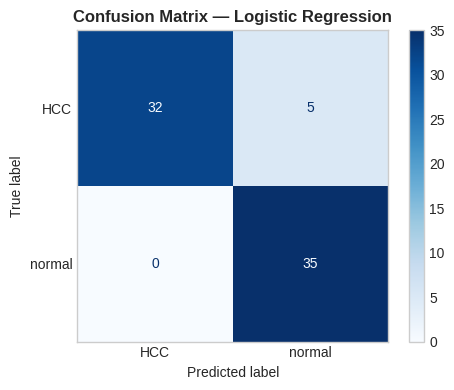

  TP (HCC correctly identified)    : 32
  TN (Normal correctly identified) : 35
  FP (Normal predicted as HCC)     : 0
  FN (HCC missed)                  : 5


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test, y_test,
    display_labels=[class_pos, class_neg],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=12, fontweight='bold')
ax.grid(False) # Turn off the grid lines for the confusion matrix
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best, labels=[class_pos, class_neg])
tp, fn, fp, tn = cm.ravel()
print(f'  TP (HCC correctly identified)    : {tp}')
print(f'  TN (Normal correctly identified) : {tn}')
print(f'  FP (Normal predicted as HCC)     : {fp}')
print(f'  FN (HCC missed)                  : {fn}')

## 9. ROC Curve

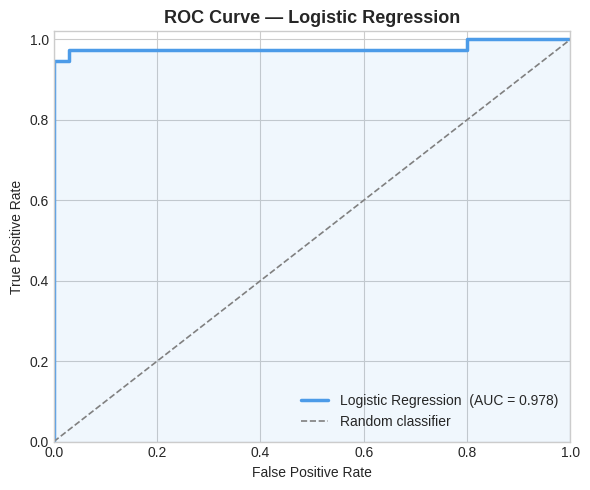

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best, pos_label=class_pos)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2.5,
        label=f'Logistic Regression  (AUC = {best_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4C9BE8')

ax.set_title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### Interpretation of the ROC Curve

* **What is an ROC Curve?** It visualises the trade-off between the True Positive Rate (how well we find actual cancers) and the False Positive Rate (how often we trigger a false alarm) at every possible classification threshold.
* **High Performance (AUC):** The tuned model achieves an AUC of 0.9776 and the baseline achieved 0.9768 — both essentially identical and both excellent. This confirms the model can almost always rank a genuine HCC sample above a normal sample in terms of predicted probability, across all thresholds.
* **Top-left hugging:** The curve stays close to the top-left corner (high TPR, low FPR), which is the ideal shape. A random classifier would follow the diagonal dashed line.

## 10. Top Feature Coefficients

In Logistic Regression, the magnitude of a feature's coefficient indicates how strongly it influences the prediction. A **positive** coefficient pushes toward HCC; a **negative** coefficient pushes toward Normal.

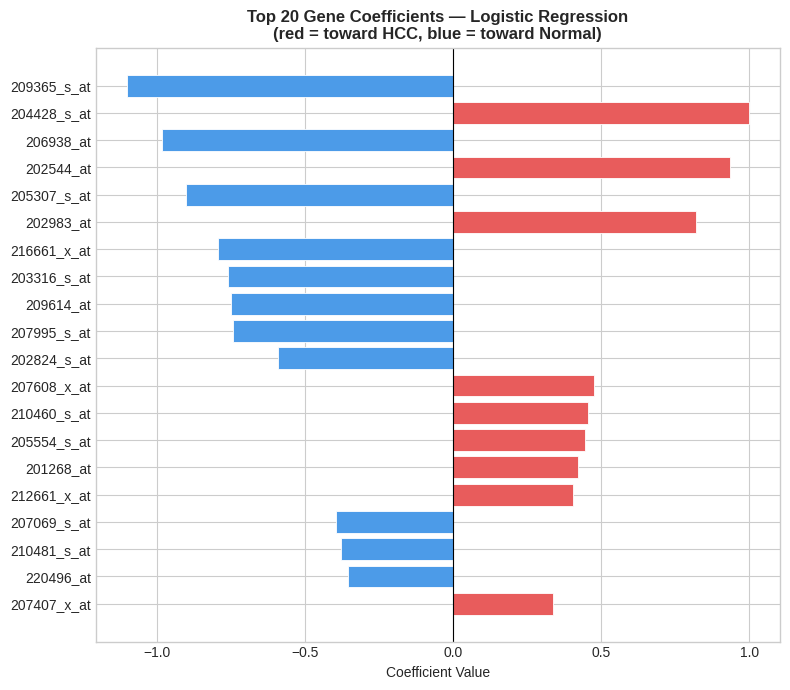

Top 10 genes by absolute coefficient:


,Gene,Coefficient
0,209365_s_at,-1.102928
1,204428_s_at,0.999364
2,206938_at,-0.985728
3,202544_at,0.935980
4,205307_s_at,-0.902625
5,202983_at,0.820607
6,216661_x_at,-0.793597
7,203316_s_at,-0.761557
8,209614_at,-0.750387
9,207995_s_at,-0.744034


In [9]:
# coef_[0] points toward classes_[1] which is "normal" (alphabetical order).
# Negate so that positive values point toward HCC, matching the red/blue colour scheme.
coef    = -best_lr.coef_[0]
coef_df = pd.DataFrame({'Gene': X_train.columns, 'Coefficient': coef})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)

bar_colors = ['#E85C5C' if c > 0 else '#4C9BE8' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coef_df['Gene'], coef_df['Coefficient'],
        color=bar_colors, edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Gene Coefficients — Logistic Regression\n(red = toward HCC, blue = toward Normal)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 genes by absolute coefficient:')
display(coef_df[['Gene', 'Coefficient']].head(10).reset_index(drop=True))

### Interpretation of Feature Coefficients

* **What this shows:** The top 20 genes with the strongest influence on the model's prediction, ranked by absolute coefficient value. Because the data was scaled in Notebook 2, all coefficients are on the same scale and can be compared directly.
* **Red Bars (Toward HCC):** Genes with positive values push the model toward predicting HCC. For example, `204428_s_at` and `202544_at` are the strongest indicators of cancer in this model.
* **Blue Bars (Toward Normal):** Genes with negative values push the model toward predicting Normal (healthy tissue). For example, `209365_s_at` and `206938_at` are the strongest indicators of healthy tissue.
* **Importance of Length:** The longer the bar, the more weight the model places on that gene. A gene with a near-zero coefficient has almost no influence on the prediction.
* **Note:** `209365_s_at` (GPC3 — Glypican-3) appears as a strong Normal indicator here in the linear model, but is the dominant HCC indicator in the Gradient Boosting model. This highlights how different model types can weigh the same gene differently depending on the interactions they capture.

## 11. Summary

In [10]:
print(f'Features used   : {X_train.shape[1]}')
print(f'Best C          : {grid_search.best_params_["C"]}')
print(f'Best penalty    : {grid_search.best_params_["penalty"]}')
print(f'Best CV F1      : {grid_search.best_score_:.4f}')
print()
print(f'Baseline  →  F1: {base_f1:.4f}  |  AUC: {base_auc:.4f}')
print(f'Tuned     →  F1: {best_f1:.4f}  |  AUC: {best_auc:.4f}')
print()
print(f'TP: {tp}  |  TN: {tn}  |  FP: {fp}  |  FN: {fn}')

Features used   : 30
Best C          : 1
Best penalty    : l2
Best CV F1      : 0.9653

Baseline  →  F1: 0.9275  |  AUC: 0.9768
Tuned     →  F1: 0.9275  |  AUC: 0.9776

TP: 32  |  TN: 35  |  FP: 0  |  FN: 5
